# **Homework5: Random walks**

 - Answer the questions marked with **Questions # )** . Just answer the parts where it says: **" write your answer here. "**
 > **You should write the codes here in this notebook and write a report for explanations in a separate pdf file.**

 * Total score: 100 score
 *  **Do not** alter the pre-written code. You can add arguments to the functions but **do not** remove any input arguments.
 *  You can use both pyg and network_x version of the dataset
 *  You can also use whatever package you want
 *   References : [Ref1](https://medium.com/@amaboh/from-deepwalk-with-random-walks-to-biased-random-walks-with-node2vec-to-improve-embeddings-582a859ed935), [Ref2](https://stellargraph.readthedocs.io/en/stable/demos/node-classification/node2vec-node-classification.html)
 *   Assume a reasonable number for unmentioned parameters
 *   If the runtime is taking long you can lower the dimension of the tensors by changing the RW parameters or sample your dataset
 *   Answer each part of the question carefully











## **Deepwalk and Node2vec**

**Question 1 ) (100 points)** After loading the Cora dataset, write two functions for random walks that get p and q as inputs and calculate random walks between two nodes. (if (p and q) == 1, it is a random walk/deep walk, else, it is Node2vec) In the first function, you can use the prewritten Biased-random walk and random walk libraries but in the second one, you should write it yourself. Can you visualize the embeddings (with PCA or T-SNE)? Split the dataset and then apply a classifier, like random forest, on the outputs of the random walk functions for the graph and compare the accuracies. How p and q affect the results? What other parameters are needed to be tuned?


#### Import Libraries

In [85]:
from torch_geometric.utils import to_networkx
from torch_geometric.datasets import Planetoid
import os
import random
import networkx as nx
import numpy as np
import seaborn as sns
from gensim.models.word2vec import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from node2vec import Node2Vec

#### Load Cora dataset

In [2]:
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

In [3]:
dataset = Planetoid(root=data_dir, name='Cora')
pyg_data = dataset[0]
labels = pyg_data.y
networkx_data = to_networkx(pyg_data, to_undirected=True)

#### Pre-wittern random walk with node2vec library

In [86]:
def pre_written_RW(graph, start_node, length, p, q):
    node2vec = Node2Vec(graph, dimensions=128, walk_length=length, num_walks=80, p=p, q=q)
    model = node2vec.fit(window=10, min_count=1)
    return model.wv

#### Custom random walk

In [5]:
def next_node(graph, previous, current, p, q):
    neighbors = list(graph.neighbors(current))
    alphas = []
    for neighbor in neighbors:
        if neighbor == previous:
            alpha = 1 / p
        elif graph.has_edge(neighbor, previous):
            alpha = 1
        else:
            alpha = 1 / q
        alphas.append(alpha)

    probs = [alpha / sum(alphas) for alpha in alphas]
    next = np.random.choice(neighbors, size=1, p=probs)[0]
    return next

def custom_RW(graph, start_node, length, p, q):
    walk = [start_node]
    for i in range(length):
        current = walk[-1]
        previous = walk[-2] if len(walk) > 1 else None
        next = next_node(graph, previous, current, p, q)
        walk.append(next)
    return [node for node in walk]


#### Calculate walks for nodes

In [6]:
walks = []
for node in networkx_data.nodes:
    for _ in range(80):
        walks.append(custom_RW(networkx_data, node, 10, 3, 2))

#### Sample walk

In [34]:
walks[1]

[0, 1862, 2582, 1166, 1986, 366, 1583, 366, 1986, 968, 1603]

#### Train work2vec model on data

In [35]:
node2vec = Word2Vec(walks,
                    hs=1,
                    sg=1,
                    vector_size=128,
                    window=10,
                    workers=2,
                    min_count=1,
                    seed=0)
node2vec.train(walks, total_examples=node2vec.corpus_count, epochs=30, report_delay=1)

(70137530, 71491200)

#### Train-test split

In [57]:
index = list(networkx_data.nodes)
random.shuffle(index)

train = index[:int(len(index)*0.8)]
test = index[int(len(index)*0.8):]

(2708, 128)

In [68]:
X = node2vec.wv[index]
y = labels.numpy()

#### PCA on data

In [59]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

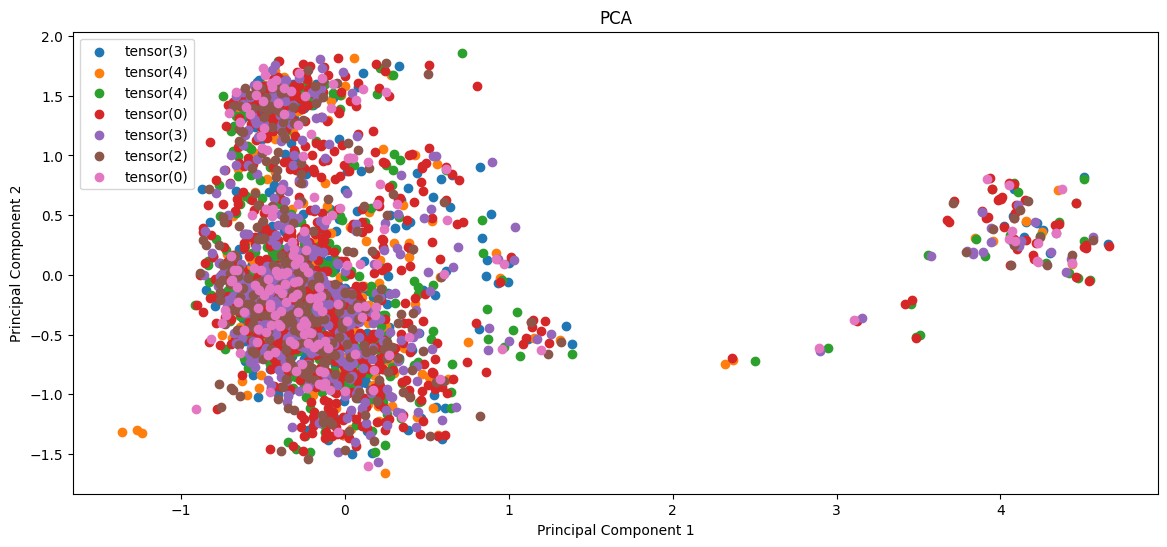

In [69]:
plt.figure(figsize=(14, 6))
for label in np.unique(y):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=labels[label])
plt.title('PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

#### t-SNE on data

In [65]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

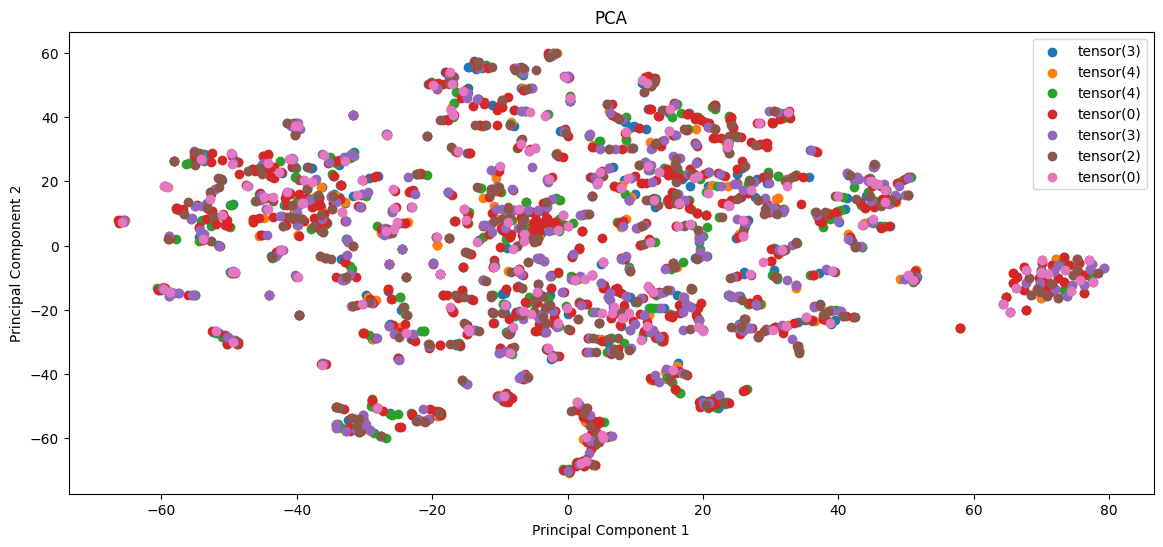

In [66]:
plt.figure(figsize=(14, 6))
for label in np.unique(y):
    plt.scatter(X_tsne[y == label, 0], X_tsne[y == label, 1], label=labels[label])
plt.title('PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

#### Random forest classifier on data

In [72]:
classifier = RandomForestClassifier(random_state=0)
classifier.fit(node2vec.wv[train], labels[train])

RandomForestClassifier(random_state=0)

In [73]:
y_pred = classifier.predict(node2vec.wv[test])

In [74]:
print('Classification Report:\n', classification_report(labels[test], y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.74      0.76        69
           1       0.82      0.85      0.84        39
           2       0.92      0.95      0.93        83
           3       0.81      0.92      0.86       158
           4       0.96      0.83      0.89        99
           5       0.87      0.84      0.85        62
           6       0.89      0.78      0.83        32

    accuracy                           0.86       542
   macro avg       0.87      0.84      0.85       542
weighted avg       0.87      0.86      0.86       542



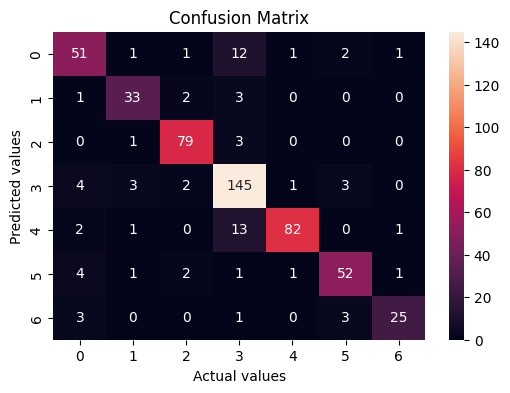

In [76]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(labels[test], y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()